# Phishing Email Detection Using Natural Language Processing: A Comparative Study of Classical Machine Learning and Transformer Models

## Modules

In [1]:
# Standard Libraries
import os
import sys
import re
import math
import time
import datetime
import pickle
from collections import Counter
from tqdm import tqdm
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

# Model Selection and Utilities
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


#Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

## Data Loading

In [2]:
# Load dataset
df = pd.read_csv('phishing_email_corpus.csv') 

# Clean Data
initial_count = len(df)
df.drop_duplicates(inplace=True)
df.dropna(subset=['email', 'label'], inplace=True)
df = df.drop(columns=["source"])
print(f"Removed {initial_count - len(df)} duplicate/null rows.")
print(f"Total Clean Emails: {df.shape[0]}")

# Check Class Balance
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

df.head()

Removed 0 duplicate/null rows.
Total Clean Emails: 44720

Class Distribution:
label
1    55.67%
0    44.33%
Name: proportion, dtype: object


,email,label
0,This text is part of the internal format of yo...,1
1,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1
2,Your two incoming mails were placed on pending...,1
3,Password will expire in 3 days. Click Here To ...,1
4,"To ensure delivery to your inbox, please add U...",1


## Preprocessing

In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
enron_signal_words = {'enron', 'ect', 'hou', 'vince', 'subject', 'cc', 'pm', 'corp'}

def preprocess_basic(email):
    if not isinstance(email, str): 
        return ""
    # Emails and URLs tokenization
    email = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,6}\b', ' email_token ', email, flags=re.IGNORECASE)
    email = re.sub(r'(?:(?:https?|ftp)[\s]*[:][\s]*/*|www[\s]*[\.])[^\s<>"]+|(?:[a-z0-9-]+[\s]*[\.])+[\s]*(?:com|org|net|edu|gov|io|cc|ly|me|info|biz|tv)\b', ' url_token ', email, flags=re.IGNORECASE)
    # Enron signals removal
    words = email.split()
    clean_words = [w for w in words if w not in enron_signal_words]
    return " ".join(clean_words)

df['email_basic'] = df['email'].apply(preprocess_basic)

def preprocess_extended(email):
    # Lowercase
    email = email.lower()
    # Remove numbers
    email = re.sub(r'\d+', ' ', email)
    # Punctuation removal (Keeping ! and ? for urgency)
    email = re.sub(r'[^\w\s!?]', ' ', email)
    # Standardize Whitespace
    words = email.split()
    # Stop Word Removal & Lemmatization
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

df['email_extended'] = df['email_basic'].apply(preprocess_extended)

## Evaluation Metrics

In [4]:
def evaluate_model(name, y_true, y_pred, y_score, start_time, X_matrix):
    duration = time.time() - start_time
    
    # Standard metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_score)
    
    return {
        'Model': name, 'Acc': acc, 'F1': f1, 'Prec': prec, 'Recall': rec,
        'ROC-AUC': roc, 'Time(s)': duration
    }

## Hyperparameter Tuning for TF-IDF Vectorizer

In [5]:
# 80%-20% Train-Test Data Split
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# Parameters 
param_grid = {
    'tfidf__max_features': [10000, 25000, 50000, 80000, 100000, None],
    'tfidf__min_df': [1, 3, 5, 7, 10], 
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_configs = {}
tuning_results = {} 

for col in ['email', 'email_basic','email_extended']:
    print(f"Tuning TF-IDF for: {col}")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))
    ])
    
    grid = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
    grid.fit(df_train[col], df_train['label'])
    best_configs[col] = grid.best_params_
    tuning_results[col] = pd.DataFrame(grid.cv_results_)

Tuning TF-IDF for: email
Tuning TF-IDF for: email_basic
Tuning TF-IDF for: email_extended


In [7]:
for col in ['email', 'email_basic', 'email_extended']:
    res_df = tuning_results[col]
    res_df['param_tfidf__max_features'] = res_df['param_tfidf__max_features'].fillna('None')
    
    min_df_comparison = res_df.groupby('param_tfidf__min_df')['mean_test_score'].mean()
    print(f"\n--- Min_DF Impact for {col} ---")
    print(min_df_comparison)
    
    pivot_table = res_df.pivot_table(index='param_tfidf__ngram_range', 
                                     columns='param_tfidf__max_features', 
                                     values='mean_test_score')
    
    print(f"\nF1-Macro Scores Matrix for {col}:")
    print(pivot_table)


--- Min_DF Impact for email ---
param_tfidf__min_df
1     0.988577
3     0.988767
5     0.988893
7     0.988805
10    0.988788
Name: mean_test_score, dtype: float64

F1-Macro Scores Matrix for email:
param_tfidf__max_features     10000     25000     50000     80000    100000  \
param_tfidf__ngram_range                                                      
(1, 1)                     0.987933  0.988304  0.988133  0.988093  0.988076   
(1, 2)                     0.988259  0.989093  0.989580  0.989545  0.989539   
(1, 3)                     0.988259  0.988752  0.989212  0.989767  0.989710   

param_tfidf__max_features      None  
param_tfidf__ngram_range             
(1, 1)                     0.987951  
(1, 2)                     0.988827  
(1, 3)                     0.988749  

--- Min_DF Impact for email_basic ---
param_tfidf__min_df
1     0.987488
3     0.987776
5     0.987848
7     0.987817
10    0.987822
Name: mean_test_score, dtype: float64

F1-Macro Scores Matrix for email_basic:


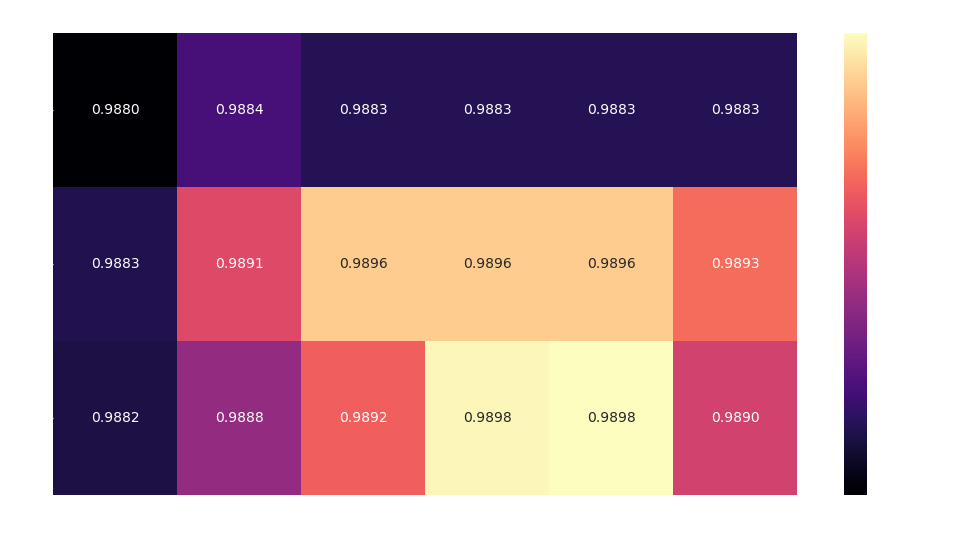

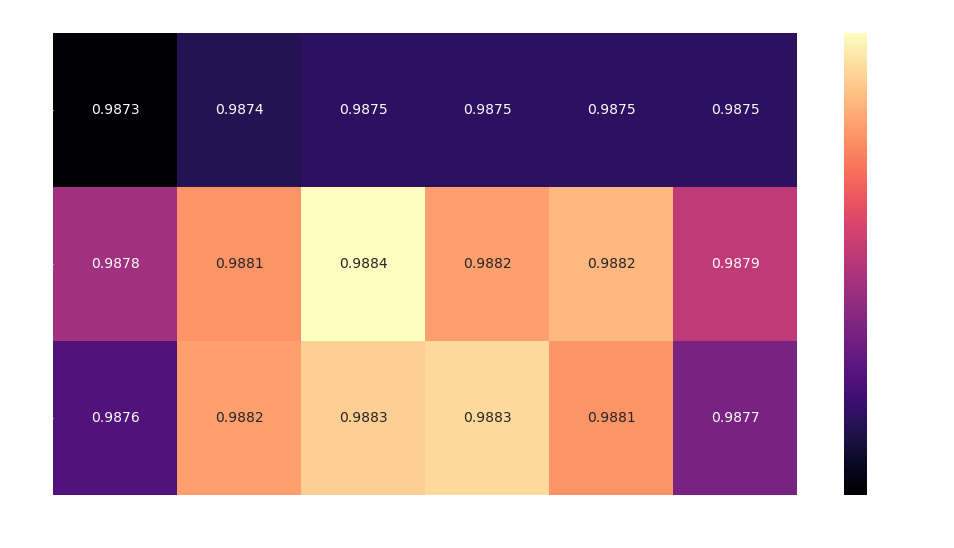

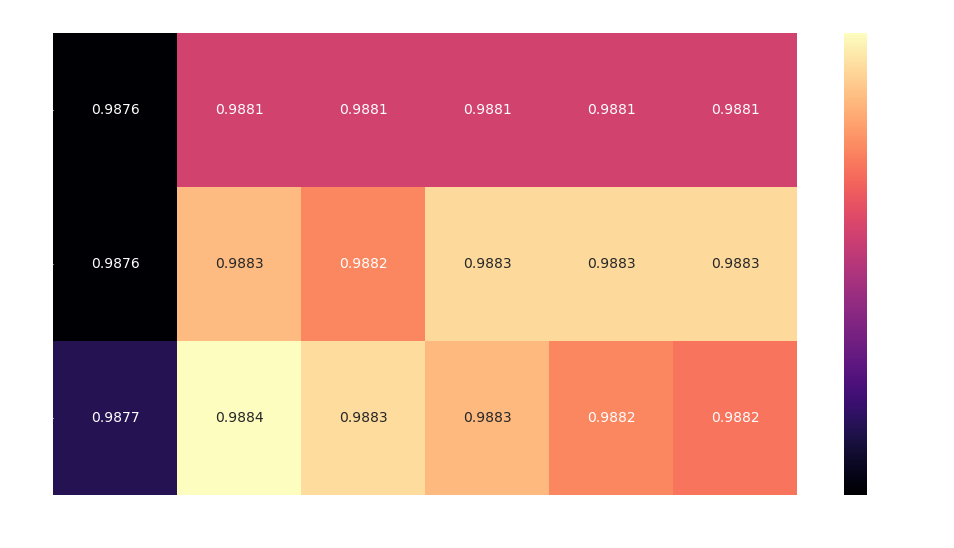

In [8]:
# HEATMAP: Interaction between parameters (max_features vs. n-gram_range).

plt.style.use('dark_background')

for col in ['email', 'email_basic', 'email_extended']:
    res_df = tuning_results[col].copy()
    best_min_df = res_df.groupby('param_tfidf__min_df')['mean_test_score'].mean().idxmax()
    
    subset = res_df[res_df['param_tfidf__min_df'] == best_min_df]
    pivot_table = subset.pivot_table(index='param_tfidf__ngram_range', 
                                     columns='param_tfidf__max_features', 
                                     values='mean_test_score',
                                     aggfunc='max')

    fig, ax = plt.subplots(figsize=(12, 6), facecolor='none')
    sns.heatmap(pivot_table.rename(columns={None: 'Unlimited'}), 
                annot=True, fmt=".4f", cmap="magma", 
                cbar_kws={'label': 'F1-Macro Score'}, ax=ax)

    plt.title(f"TF-IDF Heatmap: {col} (Fixed at best min_df={best_min_df})", fontsize=14)
    plt.xlabel("Max Features")
    plt.ylabel("N-gram Range")
    plt.show()

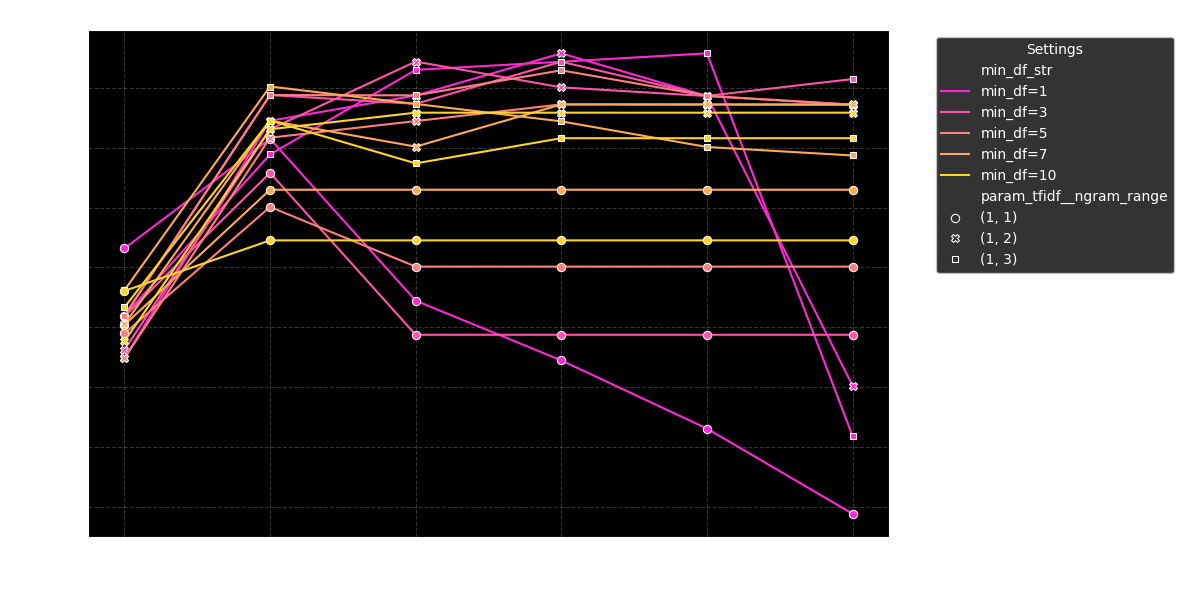

In [11]:
# LINE PLOT: Performance trends and "Saturation Point."

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(12, 6), facecolor='none')

res_df['max_feat_label'] = res_df['param_tfidf__max_features'].fillna('Unlimited').astype(str)
res_df['ngram_str'] = res_df['param_tfidf__ngram_range'].astype(str)

sns.lineplot(
    data=res_df, 
    x='max_feat_label', 
    y='mean_test_score', 
    hue='min_df_str', 
    style='param_tfidf__ngram_range',
    markers=True,
    dashes=False,
    palette='spring',
    ax=ax
)

plt.title('Performance Saturation: Does min_df filter noise?')
plt.xlabel('Vocabulary Size (Max Features)')
plt.ylabel('Mean Macro F1-Score')
plt.grid(True, linestyle='--', alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Settings')
plt.tight_layout()
plt.show()

## Model Selection

In [12]:
models_to_run = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "Multinomial NB": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC(max_iter=10000, dual=False) 
}

results_list = []

for col_name in ['email', 'email_basic', 'email_extended']:
    
    params = best_configs[col_name]
    vectorizer = TfidfVectorizer(
        max_features=params['tfidf__max_features'], 
        ngram_range=params['tfidf__ngram_range'],
        min_df=params.get('tfidf__min_df', 1)
    )
    
    X_train_final = vectorizer.fit_transform(df_train[col_name])
    X_test_final = vectorizer.transform(df_test[col_name])
    y_train = df_train['label']
    y_test = df_test['label']

    # Loop through each model
    for name, model in models_to_run.items():
        start_time = time.time()
        model.fit(X_train_final, y_train)
        y_pred = model.predict(X_test_final)

        # Handle score types for ROC-AUC
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_final)[:, 1] # LR,NB, Random F
        else:
            y_score = model.decision_function(X_test_final) # Linear SVM
        
        # Consistent evaluation
        metrics = evaluate_model(
            f"{name} ({col_name})", 
            y_test, 
            y_pred, 
            y_score, 
            start_time, 
            X_test_final, 
         )
        results_list.append(metrics)

# Comparison Table
comparison_df = pd.DataFrame(results_list)
print(comparison_df.sort_values(by='F1', ascending=False).to_string(index=False, formatters={
    'Acc': '{:,.4f}'.format, 'F1': '{:,.4f}'.format, 
    'Prec': '{:,.4f}'.format, 'Recall': '{:,.4f}'.format, 
    'ROC-AUC': '{:,.4f}'.format, 'Time(s)': '{:,.2f}'.format
}))

                               Model    Acc     F1   Prec Recall ROC-AUC Time(s)
             SVM (LinearSVC) (email) 0.9946 0.9946 0.9947 0.9944  0.9998    2.32
       SVM (LinearSVC) (email_basic) 0.9935 0.9934 0.9936 0.9932  0.9997    1.29
    SVM (LinearSVC) (email_extended) 0.9925 0.9924 0.9926 0.9922  0.9995    0.88
     Multinomial NB (email_extended) 0.9907 0.9906 0.9908 0.9904  0.9993    0.05
              Multinomial NB (email) 0.9894 0.9892 0.9891 0.9894  0.9994    0.10
         Logistic Regression (email) 0.9894 0.9892 0.9899 0.9886  0.9993    0.39
   Logistic Regression (email_basic) 0.9890 0.9889 0.9896 0.9883  0.9992    0.42
Logistic Regression (email_extended) 0.9888 0.9887 0.9893 0.9881  0.9993    0.34
        Multinomial NB (email_basic) 0.9884 0.9882 0.9883 0.9881  0.9991    0.06
      Random Forest (email_extended) 0.9875 0.9873 0.9878 0.9869  0.9987   25.26
               Random Forest (email) 0.9871 0.9870 0.9877 0.9863  0.9988   28.80
         Random Forest (emai

## Hyperparameter Tuning for Linear SVM

In [13]:
optimized_svm_results = []
final_best_configs = {}

for col_name in ['email', 'email_basic', 'email_extended']:
    print(f"\n--- Optimizing LinearSVC for: {col_name} ---")
    
    params = best_configs[col_name]
    vectorizer = TfidfVectorizer(
        max_features=params['tfidf__max_features'], 
        ngram_range=params['tfidf__ngram_range']
    )
    
    X_train_v = vectorizer.fit_transform(df_train[col_name])
    X_test_v = vectorizer.transform(df_test[col_name])
    
    # Coarse Search 
    param_grid_coarse = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    grid_coarse = GridSearchCV(LinearSVC(max_iter=10000, dual=False), 
                               param_grid_coarse, cv=skf, scoring='f1_macro', n_jobs=-1)
    grid_coarse.fit(X_train_v, y_train)
    coarse_C = grid_coarse.best_params_['C']
    
    # Refined Search 
    refined_C_values = coarse_C * np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75])
    param_grid_refined = {'C': refined_C_values}
    grid_refined = GridSearchCV(LinearSVC(max_iter=10000, dual=False), 
                                 param_grid_refined, cv=skf, scoring='f1_macro', n_jobs=-1)
    grid_refined.fit(X_train_v, y_train)
    
    final_C = grid_refined.best_params_['C']
    final_best_configs[col_name] = final_C
    print(f"Final Optimized C for {col_name}: {final_C}")
    
    # Optimized model eval
    best_svm = grid_refined.best_estimator_
    start_time = time.time()
    y_pred = best_svm.predict(X_test_v)
    y_score = best_svm.decision_function(X_test_v)
    
    metrics = evaluate_model(f"Optimized SVM ({col_name})", y_test, y_pred, y_score, start_time, X_test_v)
    optimized_svm_results.append(metrics)

opt_comparison_df = pd.DataFrame(optimized_svm_results)
print("\nFinal Optimized Results:")
print(opt_comparison_df.to_string(index=False))


--- Optimizing LinearSVC for: email ---
Final Optimized C for email: 1.75

--- Optimizing LinearSVC for: email_basic ---
Final Optimized C for email_basic: 1.0

--- Optimizing LinearSVC for: email_extended ---
Final Optimized C for email_extended: 1.75

Final Optimized Results:
                         Model      Acc       F1     Prec   Recall  ROC-AUC  Time(s)
         Optimized SVM (email) 0.994633 0.994562 0.994666 0.994461 0.999772 0.012332
   Optimized SVM (email_basic) 0.993403 0.993315 0.993484 0.993151 0.999704 0.009003
Optimized SVM (email_extended) 0.992733 0.992636 0.992752 0.992522 0.999538 0.006000


## Stability of optimized models

In [14]:
all_cv_summaries = [] # Final avg scores list

for col_name in ['email', 'email_basic', 'email_extended']:
    print(f"\n" + "="*30)
    print(f"5-Fold CV for: {col_name.upper()}")
    print("="*30)
    
    # Best parameters for each column
    best_max = best_configs[col_name]['tfidf__max_features']
    best_ngram = best_configs[col_name]['tfidf__ngram_range']
    best_C = final_best_configs[col_name]
    
    X = df[col_name]
    y = df['label']
    column_results = []

    # Stress Testing (Starified 5-Fold CV)  
    for i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        
        vec = TfidfVectorizer(max_features=best_max, ngram_range=best_ngram)
        
        Xt = vec.fit_transform(X.iloc[train_idx])
        Xv = vec.transform(X.iloc[test_idx])
        
        start_time = time.time()
        clf = LinearSVC(max_iter=10000, C=best_C, dual=False, random_state=42)
        clf.fit(Xt, y.iloc[train_idx])
        preds = clf.predict(Xv)
        scores = clf.decision_function(Xv)
        metrics = evaluate_model(f"Fold {i}", y.iloc[test_idx], preds, scores, start_time, Xt)
        column_results.append(metrics)

    cv_df = pd.DataFrame(column_results)
    print(cv_df.to_string(index=False, formatters={
        'Acc': '{:,.4f}'.format, 'F1': '{:,.4f}'.format, 
        'Prec': '{:,.4f}'.format, 'Recall': '{:,.4f}'.format, 
        'ROC-AUC': '{:,.4f}'.format, 'Time(s)': '{:,.2f}'.format,
    }))
    
    all_cv_summaries.append({
        'Column': col_name,
        'Avg F1': cv_df['F1'].mean(),
        'Std F1': cv_df['F1'].std(),
        'Avg ROC': cv_df['ROC-AUC'].mean(),
    })

summary_df = pd.DataFrame(all_cv_summaries)
print("\n--- FINAL STABILITY COMPARISON ---")
print(summary_df.to_string(index=False))


5-Fold CV for: EMAIL
 Model    Acc     F1   Prec Recall ROC-AUC Time(s)
Fold 1 0.9934 0.9933 0.9936 0.9930  0.9995    1.39
Fold 2 0.9940 0.9939 0.9941 0.9937  0.9995    1.37
Fold 3 0.9944 0.9943 0.9946 0.9941  0.9998    1.48
Fold 4 0.9949 0.9948 0.9951 0.9945  0.9997    1.24
Fold 5 0.9937 0.9937 0.9939 0.9934  0.9998    1.57

5-Fold CV for: EMAIL_BASIC
 Model    Acc     F1   Prec Recall ROC-AUC Time(s)
Fold 1 0.9926 0.9925 0.9929 0.9922  0.9995    1.14
Fold 2 0.9935 0.9934 0.9937 0.9932  0.9995    0.96
Fold 3 0.9943 0.9942 0.9944 0.9940  0.9997    0.89
Fold 4 0.9936 0.9935 0.9938 0.9933  0.9996    1.04
Fold 5 0.9931 0.9930 0.9931 0.9928  0.9997    1.01

5-Fold CV for: EMAIL_EXTENDED
 Model    Acc     F1   Prec Recall ROC-AUC Time(s)
Fold 1 0.9934 0.9933 0.9936 0.9930  0.9994    0.77
Fold 2 0.9925 0.9924 0.9927 0.9921  0.9995    1.33
Fold 3 0.9944 0.9943 0.9945 0.9942  0.9995    0.60
Fold 4 0.9933 0.9932 0.9933 0.9931  0.9995    0.76
Fold 5 0.9932 0.9931 0.9933 0.9929  0.9997    1.04



## External Validation

In [15]:
external_results = []

# Load External Data (SpamAssassin)
df_sa = pd.read_csv('SpamAssasin.csv').dropna(subset=['body'])

for col_name in ['email', 'email_basic', 'email_extended']:
    print(f"\n--- Evaluating Generalization for: {col_name} ---")
    
    best_tfidf_params = best_configs[col_name]
    best_C_val = final_best_configs[col_name]
    
    final_vectorizer = TfidfVectorizer(
        max_features=best_tfidf_params['tfidf__max_features'], 
        ngram_range=best_tfidf_params['tfidf__ngram_range'],
        min_df=best_tfidf_params.get('tfidf__min_df', 1)
    )
    
    X_internal = final_vectorizer.fit_transform(df[col_name])
    y_internal = df['label']
    
    final_clf = LinearSVC(C=best_C_val, dual=False, max_iter=10000, random_state=42)
    final_clf.fit(X_internal, y_internal)

    if col_name == 'email':
        df_sa['temp_body'] = df_sa['body']
    elif col_name == 'email_basic':
        df_sa['temp_body'] = df_sa['body'].apply(preprocess_basic)
    else: 
        df_sa['temp_body'] = df_sa['body'].apply(preprocess_basic).apply(preprocess_extended)
        
    X_external = final_vectorizer.transform(df_sa['temp_body'])
    y_sa_true = df_sa['label']
    
    y_sa_pred = final_clf.predict(X_external)
    sa_f1 = f1_score(y_sa_true, y_sa_pred, average='macro')
    
    internal_f1 = summary_df.loc[summary_df['Column'] == col_name, 'Avg F1'].values[0]
    gen_gap = internal_f1 - sa_f1
    
    external_results.append({
        'Preprocessing': col_name,
        'Internal CV F1': internal_f1,
        'External SA F1': sa_f1,
        'Generalization Gap': gen_gap
    })
    
    print(f"Internal CV F1: {internal_f1:.4f}")
    print(f"External F1:    {sa_f1:.4f}")
    print(f"Gap:            {gen_gap:.4f}")

# --- FINAL COMPARISON TABLE ---
gen_comparison_df = pd.DataFrame(external_results)
print("\n" + "="*50)
print("FINAL GENERALIZATION COMPARISON")
print("="*50)
print(gen_comparison_df.sort_values(by='Generalization Gap').to_string(index=False, formatters={
    'Internal CV F1': '{:,.4f}'.format, 
    'External SA F1': '{:,.4f}'.format, 
    'Generalization Gap': '{:,.4f}'.format
}))


--- Evaluating Generalization for: email ---
Internal CV F1: 0.9940
External F1:    0.4098
Gap:            0.5842

--- Evaluating Generalization for: email_basic ---
Internal CV F1: 0.9933
External F1:    0.5383
Gap:            0.4551

--- Evaluating Generalization for: email_extended ---
Internal CV F1: 0.9933
External F1:    0.4495
Gap:            0.5437

FINAL GENERALIZATION COMPARISON
 Preprocessing Internal CV F1 External SA F1 Generalization Gap
   email_basic         0.9933         0.5383             0.4551
email_extended         0.9933         0.4495             0.5437
         email         0.9940         0.4098             0.5842


## Mini Report


**Preprocessing**: Continuing from the data analysis, the preprocessing pipeline was split into two distinct tiers to test the impact of linguistic normalization on model performance. Basic Preprocessing focuses on structural tokenization. Using regular expressions, URLs and email addresses are collapsed into url_token and email_token. Additionally, "Enron signal words" identified are stripped here to prevent the model from learning organizational bias rather than phishing intent. Extended Preprocessing adds a layer of Morphological Normalization. By applying WordNet Lemmatization (where words are reduced to their base: *good|better|best->good*) and removing standard stopwords,while intentionally preserving "!" and "?" as urgency markers), we further reduce the feature space. This processes where done to test whether reducing words to their dictionary root helps the model generalize across different phrasing styles.

In [16]:
print(f"Sample Raw:\n{df['email'].iloc[28]}\n")
print(f"Sample Basic Preprocessing:\n{df['email_basic'].iloc[28]}\n")
print(f"Sample Extended Preprocessing:\n{df['email_extended'].iloc[28]}")

Sample Raw:
To ensure delivery to your inbox, please add USAA.Customer.Service@mailcenter.usaa.com to your address book. 	   	   	  	   Security Upgrade May Affect usaa.com Access	  View Accounts | Privacy Promise | Contact Us	  	     	 	  	 	  	 	  	   USAA SECURITY ZONE  USAA  Member  USAA # 	  	   	  	  	  	   	   	    @page Section1:first { size:8.5in 11.0in; margin-top:0.75in; margin-right:0.75in; margin-bottom:0.75in; margin-left:0.75in } #messagebody div.rcmBody div.Section1 { page:"Section1" } #messagebody div.rcmBody p.normal { font-family:"Verdana"; font-size:10.0pt; font-variant:normal; text-align:left; text-transform:none; margin-top:0.0pt; margin-right:0.0pt; margin-bottom:0.0pt; margin-left:0.0pt } #messagebody div.rcmBody table.normal { font-family:"Times New Roman"; font-size:10.0pt; font-variant:normal; text-align:left; text-transform:none; margin-top:0.0pt; margin-right:0.0pt; margin-bottom:0.0pt; margin-left:0.0pt; border-collapse:collapse }        Dear Valued Member


**Evaluation Metrics**: To ensure a rigorous and security-aware assessment of model performance, a comprehensive evaluation framework was implemented rather than relying solely on Accuracy. In phishing detection, simple Accuracy can be misleading, especially under class imbalance. A model may appear highly accurate while still failing to detect phishing emails—an unacceptable risk in a security context. Formally, the following metrics were used:

$ Accuracy = \frac{TP + TN}{TP + TN + FP + FN} $

$ Precision = \frac{TP}{TP + FP} $

$ Recall = \frac{TP}{TP + FN} $

$ F1\text{-Score} = 2 × \frac{Precision × Recall}{Precision + Recall} $

**ROC-AUC**: Area under the Receiver Operating Characteristic curve

, where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives.

Accuracy alone is insufficient because it can mask critical failures. In phishing detection, Recall must be maximized since missing even a single phishing email (FN) could result in a severe data breach. However, Precision must also remain high, otherwise excessive false positives (FP) will cause legitimate emails to be flagged, reducing user trust in the system. To balance these competing priorities, the Macro-F1 Score was used as the primary benchmark. The macro-average ensures that performance is evaluated equally across both classes, preventing dominance by the majority class. The F1 Score enforces strong performance on both Precision and Recall simultaneously, ensuring threats are detected without disrupting normal user workflow. Additionally, ROC-AUC was included to measure the model’s discriminative ability across decision thresholds.

Finally, a computational execution timer was integrated to evaluate the trade-off between model complexity and real-time inference speed, ensuring that security performance does not compromise practical deployability.


**Hyperparameter Tuning for TF-IDF Vectorizer**: The classification phase begins by establishing a baseline using a Logistic Regression classifier coupled with TF-IDF Vectorization. Before an email can be processed by a machine learning algorithm, it must be transformed from a sequence of characters into a numerical vector. We employ Term Frequency-Inverse Document Frequency (TF-IDF) to achieve this. Unlike simple bag-of-words counting (which just counts the frequency), TF-IDF balances the local importance of a term with its global rarity. The weight $W_{i,j}$ for a term $i$ in document $j$ is defined by the product of its local frequency and its global significance:

$$W_{i,j} = TF_{i,j} \times \log\left(\frac{N}{DF_i}\right)$$

Term Frequency ($TF_{i,j}$): The number of times word i appears in email j. High TF suggests the word is a central theme of that specific message.
Inverse Document Frequency ($\log(N/DF_i)$): Where N is the total number of emails and DF_i is the count of emails containing word i. This component mathematically "mutes" ubiquitous words (like "the" or "email") and amplifies rare, descriptive markers (like "cryptocurrency" or "unauthorized").

*To illustrate, consider a tiny corpus of 3 emails ($N=3$):*

*1.Email A (Phish): "Click here for account access."*
*2.Email B (Phish): "Please click this link."*
*3.Email C (Safe): "The weather is nice."*

*If we analyze the word "Click":*

•It appears once in Email A (TF=1).\
•It appears in 2 out of 3 emails (DF=2).\
•Its IDF is $\log(3/2) \approx 0.176$.\
•Final TF-IDF Weight for Email $A = 0.176$.*

In contrast, the word "The" appears in all 3 emails (DF=3), resulting in an IDF of $\log(3/3) = 0$. The math effectively assigns "The" a weight of $0.0$, rendering it invisible to the model and forcing the classifier to focus on the more discriminative "Click."*

Once the email is converted into a vector of TF-IDF weights, the Logistic Regression model performs a weighted sum of these features to determine a "suspicion score" (z). This model is particularly suited for text classification because it handles high-dimensional, sparse data efficiently via the liblinear solver—a coordinate descent algorithm. The model assigns a coefficient ($\beta$) to every token. Positive weights indicate phishing indicators, while negative weights indicate safe markers.

$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$

*Continuing with the example, if the model has learned:*

*•$\beta_{\text{Click}} = +2.5$ (Strong Phish Signal)\
•$\beta_{\text{Account}} = +1.8$ (Moderate Phish Signal)\
•$\beta_{\text{Weather}} = -3.0$ (Strong Safe Signal)\
•$\beta_0 = -0.5$ (The Intercept/Bias)*

*For Email A, the score $z$ would be:\
$$z = -0.5 + (2.5 \times 0.176) + (1.8 \times 0.22) \approx 0.336$$*

*To convert this raw score into a probability, we apply the Sigmoid Function:
$$P(\text{Phishing}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$*

*For our score of $0.336$:
$$P = \frac{1}{1 + e^{-0.336}} \approx 0.583$$*

*Since $0.583 > 0.5$, the model classifies the email as Phishing*.


To find the optimal range of hyperparameters where the model performs best, Grid Search Cross-Validation is employed. This is an exhaustive search through a manually specified subset of hyperparameters designed to combat "vocabulary inflation."During this optimization, max_features (the vocabulary budget) is tested from 10,000 to "None" (unlimited) to identify the saturation point—the moment where adding more unique tokens ceases to provide a predictive signal and instead introduces "feature noise." Simultaneously, the min_df (Minimum Document Frequency) acts as a stability filter. By testing values of $[1, 3, 5]$, we can enforce a rule where a token must appear in at least five different emails to be considered. If min\_df=5, a random string like "xkj-921" that only appears in one email is discarded. This mathematically filters out the 73.52% of tokens identified as Hapax Legomena (one-off occurrences), forcing the model to focus on repeatable phishing patterns. Furthermore, the ngram_range is tuned to capture context, moving from unigrams (single words like "account") to trigrams (phrases like "verify your account"). While a single word might be benign, the trigram serves as a high-confidence structural marker of a phishing lure.

A critical architectural decision in this implementation is the use of Stratified 5-Fold Cross-Validation instead of standard K-Fold. Since the dataset is split approximately 45/55 between classes, severe class imbalance is not expected. However, Stratified K-Fold is still used to ensure that each fold preserves the original class distribution. This means that in every training and validation split, the proportion of phishing and legitimate emails remains consistent with the overall dataset. As a result, model performance is evaluated more reliably, and variations caused by uneven class representation across folds are minimized.

The results from the grid search reveal a "Preprocessing Paradox": the raw data achieved the highest Macro-F1 score (0.9897), outperforming the cleaned and lemmatized versions. This confirms the findings from the data analysis, which identified that phishing intent is often codified in "statistical chaos"—the messy HTML, erratic casing, and punctuation patterns that professional emails lack. By stripping these away through aggressive normalization, we inadvertently removed the very "architectural fingerprints" that the model uses to distinguish machine-generated or deceptive content from organic human prose.

However, this does not mean all noise is useful. While removing structural noise (like casing) hurt performance, filtering frequency noise through the min_df setting actually stabilized the model. Our data analysis showed that over 73% of the vocabulary consisted of "Hapax Legomena" (one-off occurrences); by enforcing a minimum document frequency, we successfully discarded these unique, non-predictable artifacts. This creates a nuanced "sweet spot": the model requires the "messy" structural markers to identify phishing tactics, but it relies on frequency filters to ignore the rare, high-variance junk tokens that would otherwise lead to overfitting.

To make the inner workings of the TF-IDF vectorizer more transparent, I've added this code to demonstrate how the model converts the "Extended Preprocessing" text into the numerical weights it uses for classification.

In [20]:
sample_processed = [df['email_extended'].iloc[28]]

# Bigrams and a small feature limit for visual clarity (simulating the 'Best Config' found in the Grid Search)
demo_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_features=15  # 15 most "important" features  
)

# Fit and Transform 
tfidf_matrix = demo_vectorizer.fit_transform(sample_processed)

# Map weights to the tokens
feature_names = demo_vectorizer.get_feature_names_out()
weights = tfidf_matrix.toarray().flatten()

demo_results = pd.DataFrame({'Feature (Token)': feature_names, 'Weight (Importance)': weights})
demo_results = demo_results.sort_values(by='Weight (Importance)', ascending=False)

print("--- TF-IDF MECHANICS DEMO ---\n")
print("How the model 'sees' the sample after vectorization:\n")
print(demo_results.to_string(index=False))

# High weights (closer to 1.0) represent words that are 
# uniquely descriptive of this specific document within the corpus context.

--- TF-IDF MECHANICS DEMO ---

How the model 'sees' the sample after vectorization:

Feature (Token)  Weight (Importance)
           usaa             0.438357
         margin             0.375735
         device             0.313112
             pt             0.313112
      url_token             0.250490
         please             0.250490
        contact             0.250490
         member             0.187867
           font             0.187867
         access             0.187867
      pt margin             0.187867
         system             0.187867
       security             0.187867
        upgrade             0.187867
         update             0.187867


**Model Comparative Analysis**: Following the establishment of the Logistic Regression baseline, the project transitioned into a head-to-head evaluation of three additional architectures: Support Vector Machines (LinearSVC), Multinomial Naive Bayes, and Random Forest. This selection allowed us to test whether phishing detection is best served by margin maximization, probabilistic likelihoods, or non-linear ensembles.

Support Vector Machines (LinearSVC): This model operates by identifying the optimal hyperplane that maximizes the margin—the distance between the boundary and the nearest data points of each class (support vectors). In high-dimensional TF-IDF space, the SVM seeks the "widest road" possible to separate safe and fraudulent emails. Its decision is based on:


$$f(x) = \text{sign}(w \cdot x + b)$$

Multinomial Naive Bayes (NB): A probabilistic classifier based on Bayes’ Theorem, it assumes that the presence of one word is independent of the presence of any other. It calculates the probability of an email being phishing ($C$) given its word features ($x$) by multiplying the individual likelihoods of those words:


$$P(C|x) \propto P(C) \prod_{i=1}^{n} P(x_i|C)$$

Random Forest (RF): A non-linear ensemble method that constructs a "forest" of uncorrelated decision trees. Each tree is trained on a random subset of features (words) and data. The final classification is decided by a majority vote, where the "wisdom of the crowd" compensates for the errors of individual trees.

*To demonstrate the mathematical synergy between these models and TF-IDF, consider a simplified corpus with three features: $x_1$ (Click), $x_2$ (Verify), and $x_3$ (Meeting). A new email arrives with the following TF-IDF weights: $[0.5, 0.4, 0.1]$.*

*•SVM Logic: The model has learned weights $w = [2.0, 1.5, -3.0]$ and a bias $b = -0.5$. It calculates a score: $(0.5 \times 2.0) + (0.4 \times 1.5) + (0.1 \times -3.0) - 0.5 = 0.8$. Since the score is positive, the email is pushed to the "Phishing" side of the hyperplane.*

*•Naive Bayes Logic: The model knows that in the training set, the probability of "Click" being in a phish is $P(x_1|P)=0.7$, while in safe mail it is $P(x_1|S)=0.1$. It multiplies these likelihoods for all words. Even if one word is neutral, the strong weight of "Click" and "Verify" results in a final Phish probability of $0.92$, leading to a Phish classification.*

*•Random Forest Logic: Tree 1 asks: "Is Click > 0.3?" (Yes $\rightarrow$ Phish). Tree 2 asks: "Is Meeting > 0.5?" (No $\rightarrow$ Phish). Tree 3 asks: "Is Account in the text?" (No $\rightarrow$ Safe). By a 2-to-1 majority vote, the forest classifies the email as Phish.*

The experimental results identify LinearSVC (email) as the superior model with an F1-score of 0.9946. The SVM’s dominance on the "Raw" dataset suggests that phishing detection is fundamentally a problem of linear separability in high-dimensional space. The SVM is uniquely capable of treating "noise" tokens (like HTML tags) as structural anchors, creating a wider margin than the probabilistic approach of Logistic Regression.

Conversely, Multinomial NB performed best on the email_extended data (0.9907). This is mathematically consistent with the "Naive" assumption: by removing stop-words and lemmatizing the text, we reduced the feature dependencies, allowing the model's probabilistic logic to operate on a cleaner, more independent feature set.

Finally, the Random Forest was the least effective and most computationally expensive (28.80s). This indicates that the "decision tree" approach of splitting data into boxes is less efficient for text than the "hyperplane" approach. While text is high-dimensional, it is relatively "flat," meaning the complex non-linear branches of a Random Forest provide no advantage over the elegant linear separation of the SVM or Logistic Regression.

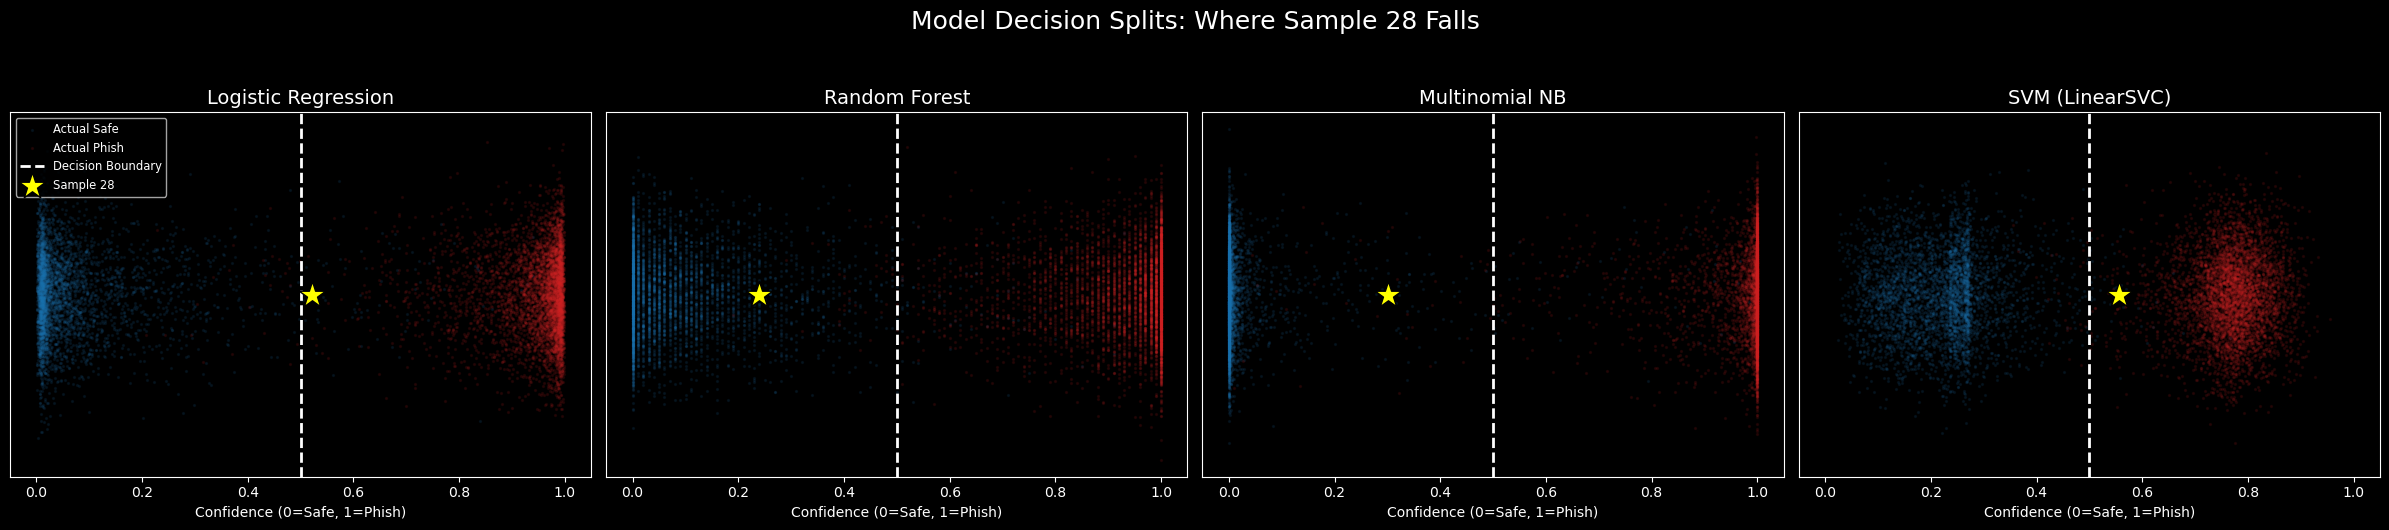

Sample 28's actual label is 1.


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
plt.style.use('dark_background')

sample_idx = 28
y_test_labels = y_test.values

for i, (name, model) in enumerate(models_to_run.items()):
    ax = axes[i]
    
    # "Confidence Score"
    # For LR, NB, and RF: Probability of class 1
    # For SVM: Decision Function (distance to hyperplane) scaled to 0-1 using Sigmoid
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_final)[:, 1]
    else:
        d = model.decision_function(X_test_final)
        scores = 1 / (1 + np.exp(-d)) 

    jitter = np.random.normal(0, 0.05, size=len(scores)) # Only for vizualization purposes
    
    # Safe emails Blue, Phishing emails Red
    ax.scatter(scores[y_test_labels == 0], jitter[y_test_labels == 0], 
               color='#1f77b4', alpha=0.1, s=2, label='Actual Safe')
    ax.scatter(scores[y_test_labels == 1], jitter[y_test_labels == 1], 
               color='#d62728', alpha=0.1, s=2, label='Actual Phish')

    ax.axvline(0.5, color='white', linestyle='--', linewidth=2, label='Decision Boundary')

    sample_score = scores[sample_idx]
    ax.scatter(sample_score, 0, color='yellow', edgecolors='black', 
               s=400, marker='*', zorder=10, label=f'Sample {sample_idx}')

    # Formatting
    ax.set_title(f"{name}", fontsize=14)
    ax.set_xlim(-0.05, 1.05)
    ax.set_yticks([]) 
    ax.set_xlabel("Confidence (0=Safe, 1=Phish)")
    
    if i == 0:
        ax.legend(loc='upper left', fontsize='small')

plt.suptitle(f"Model Decision Splits: Where Sample {sample_idx} Falls", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

print(f"Sample 28's actual label is {df['label'].iloc[28]}.")

**Hyperparameter Tuning for Linear SVM**

**Hyperparameter Tuning for Linear SVM**: To extract the maximum predictive power from our top-performing architecture, we implemented a dual-stage optimization strategy for the LinearSVC model. While the previous comparison established the SVM as the superior classifier, this stage focuses on tuning the Regularization Parameter (C), which governs the fundamental trade-off between maximizing the margin width and minimizing training classification errors.

In a Linear SVM, the goal is to find a weight vector $w$ and a bias $b$ that solves the following optimization problem:

$$\min_{w, b, \zeta} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \zeta_i$$

Subject to the constraint: $y_i(w \cdot x_i + b) \geq 1 - \zeta_i$

Here, $\zeta_i$ represents "slack variables" that allow certain data points to fall on the wrong side of the margin to prevent overfitting. The parameter $C$ acts as a penalty weight:

* Small $C$: Prioritizes a larger margin (simpler model), even if it misclassifies some training points.
* Large $C$: Penalizes misclassifications heavily, forcing the model to create a more complex boundary to "get every point right."

*To illustrate the synergy between TF-IDF and C, consider two emails with weights for "url_token" ($x_1$) and "subject_line" ($x_2$):*

•Email A (Phish): $[0.8, 0.2]$

•Email B (Safe): $[0.7, 0.3]$ (A borderline case)

*If we set $C = 0.01$ (Soft Margin), the model might decide that the $0.1$ difference in TF-IDF weights is just "noise." It draws a wide, simple boundary that might misclassify Email B as Phish to keep the "road" wide and stable.*

*If we set $C = 100$ (Hard Margin), the model treats that $0.1$ difference as a critical signal. It will shift the hyperplane specifically to ensure Email B is on the "Safe" side. While this increases accuracy on the training set, it risks "overfitting" to specific phrasing that might not appear in future phishing emails.*

To find the "sweet spot" for $C$, we utilized a two-step search. First, a Coarse Search tested powers of ten ($0.001$ to $100$) to identify the correct order of magnitude. Second, a Refined Search explored the immediate neighborhood of the best coarse value (e.g., $1.75 \times$ the coarse best). This allowed us to pinpoint the optimal penalty without the computational cost of a dense search across the entire range.

The optimization process concluded with near-perfect F1-scores across all preprocessing tiers, specifically reaching 0.9946 for raw emails ($C=1.75$), 0.9933 for basic preprocessing ($C=1.0$) and 0.9926 for extended preprocessing ($C=1.75$). This consistent performance suggests that, while the raw text contains the strongest structural "noise" markers, the underlying phishing signals are sufficiently robust to maintain high accuracy regardless of the level of linguistic normalization applied.

**External Validation**: To determine the real-world utility of the optimized LinearSVC, the model was subjected to an "out-of-distribution" stress test using the SpamAssassin dataset. This represents a rigorous evaluation of the generalization gap—the difference between performance on known historical patterns (Internal CV) and a completely unseen environment (External Validation).

The results reveal a significant performance drop across all tiers, yet they highlight a critical finding regarding data preparation. The email_basic preprocessing achieved the highest external F1-score (0.5383) and the smallest generalization gap (0.4551). This confirms that by neutralizing the Enron organizational bias while preserving structural markers like "url_token," the model learned more robust features of phishing than the raw or over-cleaned versions. While the raw email tier performed best internally, its massive generalization gap (0.5842) suggests it overfit to specific architectural "noise" unique to the training corpus, which failed to translate to the different formatting of the SpamAssassin dataset.

**Conclusion**: This project demonstrates that while classical machine learning models like the Linear SVM can achieve near-perfect accuracy (0.99+) within a controlled, multi-generational corpus, they remain highly susceptible to "Zero-Day" vulnerabilities. The high internal scores are indicative of a model that has mastered the specific vocabulary and statistical chaos of its training data. However, the collapse in external performance illustrates that these models rely on static linguistic patterns that do not always persist across different eras or organizations.

Ultimately, phishing detection is a "moving target" problem. Classical models excel at identifying known historical lures through TF-IDF weighting and margin maximization, but they lack the semantic flexibility to adapt to novel, zero-day social engineering tactics. To bridge this generalization gap, the project must move beyond static word-frequency analysis and toward Transformer-based architectures that can model the underlying intent and contextual meaning of an email, rather than just its statistical signatures.